<a href="https://colab.research.google.com/github/DONCHAN-ML/AGRI-SMART-UPOLABDHI-Backend/blob/main/AmazonProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error



In [21]:
train_df = pd.read_csv('/content/train.csv', on_bad_lines='skip', engine='python')
test_df = pd.read_csv('/content/test.csv', on_bad_lines='skip', engine='python')

In [22]:
df = train_df

In [23]:
df.head(5)

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [24]:
df.shape

(75000, 4)

In [25]:
df.isnull().sum()

,0
sample_id,0
catalog_content,0
image_link,0
price,0


<Axes: xlabel='sample_id', ylabel='sample_id'>

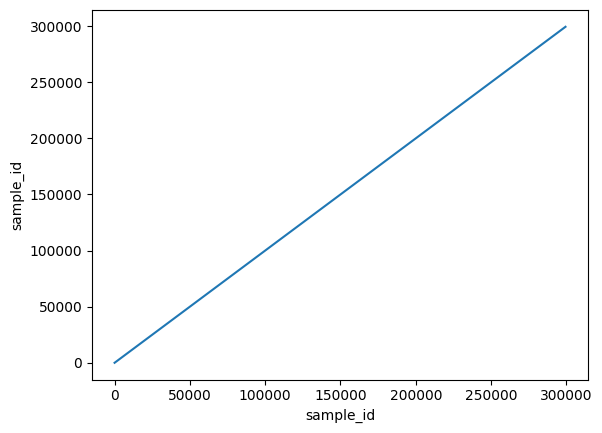

In [26]:
sns.lineplot(x='sample_id', y='sample_id', data=df)

In [27]:
df['price'].min()

0.13

In [28]:
df['price'].max()

2796.0

In [29]:
df['catalog_content'] = df['catalog_content'].str.split(':').str[1]

In [30]:
df['price'].shape, df['catalog_content'].shape, df['sample_id'].shape

((75000,), (75000,), (75000,))

In [31]:
df.head(3)

,sample_id,catalog_content,image_link,price
0,33127,"La Victoria Green Taco Sauce Mild, 12 Ounce (...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Salerno Cookies, The Original Butter Cookies,...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Bear Creek Hearty Soup Bowl, Creamy Chicken w...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97


In [32]:
def clean_text(text):
    return str(text).lower().strip()

train_df['catalog_content'] = train_df['catalog_content'].apply(clean_text)
test_df['catalog_content'] = test_df['catalog_content'].apply(clean_text)


In [33]:
train_df['catalog_content']

,catalog_content
0,"la victoria green taco sauce mild, 12 ounce (p..."
1,"salerno cookies, the original butter cookies, ..."
2,"bear creek hearty soup bowl, creamy chicken wi..."
3,judee’s blue cheese powder 11.25 oz - gluten-f...
4,"kedem sherry cooking wine, 12.7 ounce - 12 per..."
...,...
74995,"ice breakers spearmint sugar free mints tins, ..."
74996,"davidson's organics, vanilla essence, 100-coun..."
74997,jolly rancher hard candy - blue raspberry - 5 ...
74998,nescafe dolce gusto capsules - caramel macchia...


In [35]:
train_df['catalog_content'].shape

(75000,)

In [36]:
test_df['catalog_content'].shape

(75000,)

In [34]:
test_df['catalog_content']

,catalog_content
0,item name: rani 14-spice eshamaya's mango chut...
1,item name: natural milk tea flavoring extract ...
2,item name: honey filled hard candy - bulk pack...
3,item name: vlasic snack'mm's kosher dill 16 oz...
4,"item name: mccormick culinary vanilla extract,..."
...,...
74995,item name: good seasons zezty italian salad dr...
74996,"item name: colombina swirled love tiger pops, ..."
74997,"item name: kerns, guava nectar, 11.5 fl oz can..."
74998,item name: ny spice shop licorice candy - 1 po...


In [37]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_text = vectorizer.fit_transform(train_df['catalog_content'])
X_test_text = vectorizer.transform(test_df['catalog_content'])

In [40]:
X_test_text.shape

(75000, 5000)

In [39]:
X_train_text.shape

(75000, 5000)

In [11]:
y_train = train_df['price']

In [12]:
model = LGBMRegressor(n_estimators=300, learning_rate=0.1, random_state=42)
model.fit(X_train_text, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.696725 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 118611
[LightGBM] [Info] Number of data points in the train set: 6485, number of used features: 2811
[LightGBM] [Info] Start training from score 24.248383


LGBMRegressor(n_estimators=300, random_state=42)

In [13]:
y_pred = model.predict(X_test_text)
y_pred = np.clip(y_pred, a_min=0.01, a_max=None)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [19]:
import numpy as np

def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_score = np.mean(numerator / denominator) * 100
    return smape_score


score = smape(y, y_pred)
print(f"SMAPE: {score:.2f}%")

ValueError: operands could not be broadcast together with shapes (6485,) (5430,) 

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)


smape_score = smape(y_val, y_val_pred)

In [14]:
submission = pd.DataFrame({
    'sample_id': test_df['sample_id'],
    'price': y_pred.round(2)
})
submission.to_csv('test_out.csv', index=False)
print("✅ Submission file 'test_out.csv' created.")


✅ Submission file 'test_out.csv' created.


In [15]:
from PIL import Image
import requests
from torchvision import models, transforms
import torch


resnet = models.resnet18(pretrained=True)
resnet.eval()


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def get_image_embedding(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img_tensor = transform(img).unsqueeze(0)
        with torch.no_grad():
            embedding = resnet(img_tensor).squeeze().numpy()
        return embedding
    except:
        return np.zeros(512)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


In [18]:
if submission.shape[0] != test_df.shape[0]:
    print('Row count mismatch! Check your prediction loop.....')
else :
  print('Row count match. Check your prediction.....')
if not all(submission['price'] > 0):
    print('Some predicted prices are zero or negative....')
else :
  print("Some predicted prices is correct....")

Row count match. Check your prediction.....
Some predicted prices is correct....
